# Multivariate root-finding from Newton-Raphson method

 <div style="width: 100%; overflow: hidden;">
     <div style="width: 75%; float: left;">
         In this notebook, the Newton-Raphson method is employed to solve for an intersection of three ellipsoid bodies via root-finding. The animation below depicts an exemplary ellipsoid surface rotating around its vertical axis. <br>
         <img src="./img/ellipsoid_anim.gif" style="width:350px;text-align:left;vertical-align: middle;"/><br>
         last update: 16/11/2020
     </div>
     <div style="margin-left: 80%;">
        <b>Author</b><br><br>
        <a href='http://www.christopherhahne.de', style="text-decoration: None; text-align: left;">
            <img align="left" src="http://www.christopherhahne.de/images/about.jpg" width="78"/>
            <br><br><br><br><br><br>
            <b>Christopher<br>Hahne, PhD</b>
        </a>
    </div>
</div>

## Surface geometry of an ellipsoid

Any point $\mathbf{p}_i$ on an ellispoid surface $Q\left(\mathbf{p}_i, \mathbf{r}\right)$ is defined as

$$ 
Q\left(\mathbf{p}_i, \mathbf{r}\right) = 
\left(\frac{x_i}{r_1}\right)^2 + \left(\frac{y_i}{r_2}\right)^2 + \left(\frac{z_i}{r_3}\right)^2-1
$$

where $\mathbf{p}_i=\left(x_i, y_i, z_i\right)^\intercal$ and $\mathbf{r}=\left(r_1, r_2, r_3\right)^\intercal$. However, the above statement only holds for ellipsoids whose center resides on the coordinate origin and whose axes $\mathbf{r}$ are in line with the coordinate axes.

In the more general case, an ellipsoidal surface $Q(\cdot)$ with space coordinates $\mathbf{\hat{p}}$ may be at any location $\mathbf{c}=(x_c, y_c, z_c)^\intercal$ with an arbitrary orientation $\mathbf{R}$ so that

$$
\mathbf{\hat{p}}_i=\mathbf{R}\mathbf{p}_i+\mathbf{c}
$$

which is re-arranged to

$$
\mathbf{p}_i = \mathbf{R}^{-1}\left(\mathbf{\hat{p}}_i-\mathbf{c}\right)
$$

with the inverse $\mathbf{R}^{-1}$ of a three-dimensional rotation matrix $\mathbf{R} \in \mathbb{R}^{3 \times 3}$ reads

$$
\mathbf{R} = 
\begin{bmatrix}
\cos\alpha\cos\beta & \cos\alpha\sin\beta\sin\gamma - \sin\alpha\cos\gamma & \cos\alpha\sin\beta\cos\gamma + \sin\alpha\sin\gamma \\
\sin\alpha\cos\beta & \sin\alpha\sin\beta\sin\gamma + \cos\alpha\cos\gamma & \sin\alpha\sin\beta\cos\gamma - \cos\alpha\sin\gamma \\
-\sin\beta & \cos\beta\sin\gamma & \cos\beta\cos\gamma \\
\end{bmatrix}
\label{eq:rota}\tag{3}
$$

while for simplicity $\mathbf{R}^{-1}$ is defined to be

$$
\mathbf{R}^{-1} =
\begin{bmatrix}
c_{11} & c_{12} & c_{13} \\
c_{21} & c_{22} & c_{23} \\
c_{31} & c_{32} & c_{33} \\
\end{bmatrix}
$$

allowing us to write

$$
\begin{bmatrix} x_i \\ y_i \\ z_i \end{bmatrix}=
\begin{bmatrix}
c_{11} & c_{12} & c_{13} \\
c_{21} & c_{22} & c_{23} \\
c_{31} & c_{32} & c_{33} \\
\end{bmatrix}
\begin{bmatrix} \hat{x}_i - x_c \\ \hat{y}_i - y_c \\ \hat{z}_i - z_c \end{bmatrix}
$$

and multiply

$$
\begin{bmatrix} x_i \\ y_i \\ z_i \end{bmatrix}=
\begin{bmatrix}
(\hat{x}_i-x_c) c_{11} + (\hat{y}_i-x_c) c_{12} + (\hat{z}_i-x_c) c_{13} \\
(\hat{x}_i-y_c) c_{21} + (\hat{y}_i-y_c) c_{22} + (\hat{z}_i-y_c) c_{23} \\
(\hat{x}_i-z_c) c_{31} + (\hat{y}_i-z_c) c_{32} + (\hat{z}_i-z_c) c_{33} \\
\end{bmatrix}
$$

This is fed into the surface function $Q(\cdot)$ giving

$
Q\left(\mathbf{\hat{p}}_i, \mathbf{r}, \mathbf{R}^{-1}, \mathbf{c}\right) = 
\left(\frac{(\hat{x}_i-x_c) c_{11} + (\hat{y}_i-x_c) c_{12} + (\hat{z}_i-x_c) c_{13}}{r_1}\right)^2 + 
\left(\frac{(\hat{x}_i-y_c) c_{21} + (\hat{y}_i-y_c) c_{22} + (\hat{z}_i-y_c) c_{23}}{r_2}\right)^2 + 
\left(\frac{(\hat{x}_i-z_c) c_{31} + (\hat{y}_i-z_c) c_{32} + (\hat{z}_i-z_c) c_{33}}{r_3}\right)^2 - 1
$

which we use for each ellipsoid body placed relative to the origin.

## Partial derivatives of ellipsoid surface

To solve for intersections of ellipsoids, we seek the partial derivatives of the surface function $Q(\cdot)$ using the [chain rule](https://en.wikipedia.org/wiki/Chain_rule) which results in

$
\partial_\hat{x}Q\left(\mathbf{\hat{p}}_i, \mathbf{r}, \mathbf{R}^{-1}, \mathbf{c}\right) = 
2\left(\frac{c_{11}}{r_1}\left(\frac{(\hat{x}_i-x_c) c_{11} + (\hat{y}_i-x_c) c_{12} + (\hat{z}_i-x_c) c_{13}}{r_1}\right) + 
\frac{c_{21}}{r_2}\left(\frac{(\hat{x}_i-y_c) c_{21} + (\hat{y}_i-y_c) c_{22} + (\hat{z}_i-y_c) c_{23}}{r_2}\right) + \
\frac{c_{31}}{r_3}\left(\frac{(\hat{x}_i-z_c) c_{31} + (\hat{y}_i-z_c) c_{32} + (\hat{z}_i-z_c) c_{33}}{r_3}\right) \right)
$

$
\partial_\hat{x}Q\left(\mathbf{\hat{p}}_i, \mathbf{r}, \mathbf{R}^{-1}, \mathbf{c}\right) = 2\left(
\frac{(\hat{x}_i-x_c) c_{11}^2 + (\hat{y}_i-x_c) c_{11}c_{12} + (\hat{z}_i-x_c) c_{11}c_{13}}{r_1^2} + \
\frac{(\hat{x}_i-y_c) c_{21}^2 + (\hat{y}_i-y_c) c_{21}c_{22} + (\hat{z}_i-y_c) c_{21}c_{23}}{r_2^2} + \
\frac{(\hat{x}_i-z_c) c_{31}^2 + (\hat{y}_i-z_c) c_{31}c_{32} + (\hat{z}_i-z_c) c_{31}c_{33}}{r_3^2} \right)
$

$
\partial_\hat{x}^2Q\left(\mathbf{\hat{p}}_i, \mathbf{r}, \mathbf{R}^{-1}, \mathbf{c}\right) = 2\left(
\frac{c_{11}^2}{r_1^2} + \frac{c_{21}^2}{r_2^2} + \frac{c_{31}^2}{r_3^2} \right)
$

## Ellipsoid class implementation

The above statements on ellipsoid surface properties are implemented as a class.

In [1]:
import numpy as np

class Ellipsoid(object):

    def __init__(self, cen_pos=(0, 0, 0), axs_len=(1, 1, 1), rot_xyz=(0, 0, 0), coords_num=None):

        self.cen_pos = np.array(cen_pos)
        self.rot_xyz = np.array(rot_xyz)
        self.axs_len = np.array(axs_len)

        # initialize radii vectors
        self.axs_vec = np.zeros((3, 3))
        self.calc_radii_vectors()

        # provide n as imaginary number to serve number of samples to mgrid
        self._n = np.complex(0, 31) if coords_num is None else np.complex(0, coords_num)
        self.phi, self.theta = np.mgrid[0:np.pi:self._n, 0:2 * np.pi:self._n]

    def calc_radii_vectors(self):

        # compute 3D axes vectors of ellipsoid
        for i in range(3):
            axs_vec = np.zeros(3)
            axs_vec[i] = 1 * self.axs_len[i]
            self.axs_vec[i] = np.dot(self.rot_mat, axs_vec)

    @property
    def rot_mat(self):
        """ create rotation matrix from angles [deg] """

        x, y, z = self.rot_xyz / 180 * np.pi

        rot_x = np.array([[1, 0, 0], [0, np.cos(x), -np.sin(x)], [0, np.sin(x), np.cos(x)]])
        rot_y = np.array([[np.cos(y), 0, np.sin(y)], [0, 1, 0], [-np.sin(y), 0, np.cos(y)]])
        rot_z = np.array([[np.cos(z), -np.sin(z), 0], [np.sin(z), np.cos(z), 0], [0, 0, 1]])

        return np.dot(rot_z, np.dot(rot_y, rot_x))

    @property
    def coords_origin(self):

        x = self.axs_len[0] * np.sin(self.phi) * np.cos(self.theta)
        y = self.axs_len[1] * np.sin(self.phi) * np.sin(self.theta)
        z = self.axs_len[2] * np.cos(self.phi)

        return np.array([x, y, z])

    @property
    def coords(self):

        # spherical coordinate parametrization
        x, y, z = self.coords_origin

        # rotate ellipsoidal coordinates around origin
        x, y, z = np.dot(self.rot_mat, np.array([x.flatten(), y.flatten(), z.flatten()]))

        # translate coordinates to relative position in space
        x, y, z = x + self.cen_pos[0], y + self.cen_pos[1], z + self.cen_pos[2]

        return np.array([x.reshape(self.phi.shape), y.reshape(self.phi.shape), z.reshape(self.phi.shape)])

    def Q(self, p):
        """ surface equation for displaced and rotated ellipsoidal points """
        
        R_inv = np.linalg.inv(self.rot_mat)
        
        p_cen = (p - self.cen_pos.T).T
        
        Q = ((p_cen[0]*R_inv[0][0] + p_cen[1]*R_inv[0][1] + p_cen[2]*R_inv[0][2]) / self.axs_len[0])**2 + \
            ((p_cen[0]*R_inv[1][0] + p_cen[1]*R_inv[1][1] + p_cen[2]*R_inv[1][2]) / self.axs_len[1])**2 + \
            ((p_cen[0]*R_inv[2][0] + p_cen[1]*R_inv[2][1] + p_cen[2]*R_inv[2][2]) / self.axs_len[2])**2 - 1
        
        return Q
    
    def pd1Q(self, p, var_idx=0):
        """ partial derivative of surface equation with respect to variable index """
        
        R_inv = np.linalg.inv(self.rot_mat)
        
        p_cen = (p - self.cen_pos.T).T
        
        pd1Q = 2*(R_inv[0][var_idx]/self.axs_len[0]*(
                  (p_cen[0]*R_inv[0][0] + p_cen[1]*R_inv[0][1] + p_cen[2]*R_inv[0][2]) / self.axs_len[0]) + \
                  R_inv[1][var_idx]/self.axs_len[1]*(
                  (p_cen[0]*R_inv[1][0] + p_cen[1]*R_inv[1][1] + p_cen[2]*R_inv[1][2]) / self.axs_len[1]) + \
                  R_inv[2][var_idx]/self.axs_len[2]*(
                  (p_cen[0]*R_inv[2][0] + p_cen[1]*R_inv[2][1] + p_cen[2]*R_inv[2][2]) / self.axs_len[2])
                 )
        
        return pd1Q

In [2]:
# ellipsoid instantiation
elp_a = Ellipsoid(axs_len=(1, 2, 2), rot_xyz=(10, 0, 0), cen_pos=(2,-1, 2))
elp_b = Ellipsoid(axs_len=(1, 1, 3), rot_xyz=(0, 10, 0), cen_pos=(1, 0, 2))
elp_c = Ellipsoid(axs_len=(1, 2, 1), rot_xyz=(0, 0, 50), cen_pos=(1,-1, 2))

# test if displaced, rotated coordinates at Q surface - expected zeros
x, y, z = elp_c.coords
pts_list = np.array([x.flatten(), y.flatten(), z.flatten()]).T
res = all(elp_c.Q(pts_list) < 10**-11)
print(res)

True


## Newton-Raphson implementation

In the following we implement the first-order Newton method in multivariate fashion given by

$$
\mathbf{p}_{i+1}=\mathbf{p}_i - \big[\mathbf{J}\left(\mathbf{p}_i\right)\big]^{-1}\mathbf{f}\left(\mathbf{p}_i\right)
$$

where three ellipsoid surfaces are covered in $\mathbf{f}(\mathbf{p}_i)$ which reads

$$
\mathbf f\left(\mathbf{p}_i\right) = 
  \begin{bmatrix} 
  Q\left(\mathbf{\hat{p}}_i, \mathbf{r}_a, \mathbf{R}^{-1}_a, \mathbf{c}_a\right) \\[1em]
  Q\left(\mathbf{\hat{p}}_i, \mathbf{r}_b, \mathbf{R}^{-1}_b, \mathbf{c}_b\right) \\[1em]
  Q\left(\mathbf{\hat{p}}_i, \mathbf{r}_c, \mathbf{R}^{-1}_c, \mathbf{c}_c\right) \\[1em]
  \end{bmatrix}
$$

while $\mathbf{J}(\mathbf{p}_i)$ is composed by the corresponding partial derivatives giving

$$
\mathbf{J}\left(\mathbf{p}_i\right) = 
\begin{bmatrix}
  \partial_\hat{x}Q\left(\mathbf{p_i}, \mathbf{r}_a, \mathbf{R}^{-1}_a, \mathbf{c}_a\right) & 
  \partial_\hat{y}Q\left(\mathbf{p_i}, \mathbf{r}_a, \mathbf{R}^{-1}_a, \mathbf{c}_a\right) & 
  \partial_\hat{z}Q\left(\mathbf{p_i}, \mathbf{r}_a, \mathbf{R}^{-1}_a, \mathbf{c}_a\right) \\[1em]
  \partial_\hat{x}Q\left(\mathbf{p_i}, \mathbf{r}_b, \mathbf{R}^{-1}_b, \mathbf{c}_b\right) & 
  \partial_\hat{y}Q\left(\mathbf{p_i}, \mathbf{r}_b, \mathbf{R}^{-1}_b, \mathbf{c}_b\right) & 
  \partial_\hat{z}Q\left(\mathbf{p_i}, \mathbf{r}_b, \mathbf{R}^{-1}_b, \mathbf{c}_b\right) \\[1em]
  \partial_\hat{x}Q\left(\mathbf{p_i}, \mathbf{r}_c, \mathbf{R}^{-1}_c, \mathbf{c}_c\right) & 
  \partial_\hat{y}Q\left(\mathbf{p_i}, \mathbf{r}_c, \mathbf{R}^{-1}_c, \mathbf{c}_c\right) & 
  \partial_\hat{z}Q\left(\mathbf{p_i}, \mathbf{r}_c, \mathbf{R}^{-1}_c, \mathbf{c}_c\right) \\[1em]
 \end{bmatrix}
$$

In [3]:
def multivar_newton(p, functional, jacobian, l=1, tol=1e-15, eps=1):
    p_list = []
    while tol<eps<200:
        p_list.append(p.copy())
        f = functional(p)
        J = jacobian(p)
        p -= l*np.dot(np.linalg.inv(J), f)
        eps = np.sum(np.abs(f))
    return p_list, eps

In [4]:
functional = lambda p: [elp_a.Q(p), elp_b.Q(p), elp_c.Q(p)]

In [5]:
def jacobian(p):
    J = [[elp_a.pd1Q(p, 0), elp_a.pd1Q(p, 1), elp_a.pd1Q(p, 2)], 
         [elp_b.pd1Q(p, 0), elp_b.pd1Q(p, 1), elp_b.pd1Q(p, 2)],
         [elp_c.pd1Q(p, 0), elp_c.pd1Q(p, 1), elp_c.pd1Q(p, 2)]]
    return J

## Find intersection

For the initial guess, we choose a point $\mathbf{p}_s$ on the surface of an ellipsoid that is somewhat close to the other surfaces.

In [6]:
# initial guess
x, y, z = elp_a.coords
pts_list = np.array([x.flatten(), y.flatten(), z.flatten()]).T
idx = np.random.randint(len(pts_list))#0 #
p_s = pts_list[idx].copy()

bs = elp_b.Q(pts_list)
cs = elp_c.Q(pts_list)
qs = bs**2 * cs**2
#p_s = pts_list[np.argmin(qs)]

# run
pts, eps = multivar_newton(p_s, functional, jacobian, l=1)

# result
print("The final guess is found at %s after %s iterations with a total error of %s." % (pts[-1], len(pts), eps))

The final guess is found at [ 1.13162018 -0.89965786  1.01328961] after 9 iterations with a total error of 2.220446049250313e-16.


## Validation of the solution
To evaluate our final point $\mathbf{p}^\star$, we plug it into the surface equation $Q(\mathbf{p}^\star, \mathbf{r}, \mathbf{R}^{-1}, \mathbf{c})$ of each ellipsoid while we expect the results to be close to zero.

In [7]:
valid_test = [elp_a.Q(pts[-1]), elp_b.Q(pts[-1]), elp_c.Q(pts[-1])]
print(valid_test)
print('Solution is valid') if all(np.array(valid_test) < 1e-11) else print('Validation failed')

[0.0, 0.0, 2.220446049250313e-16]
Solution is valid


<IPython.core.display.Javascript object>


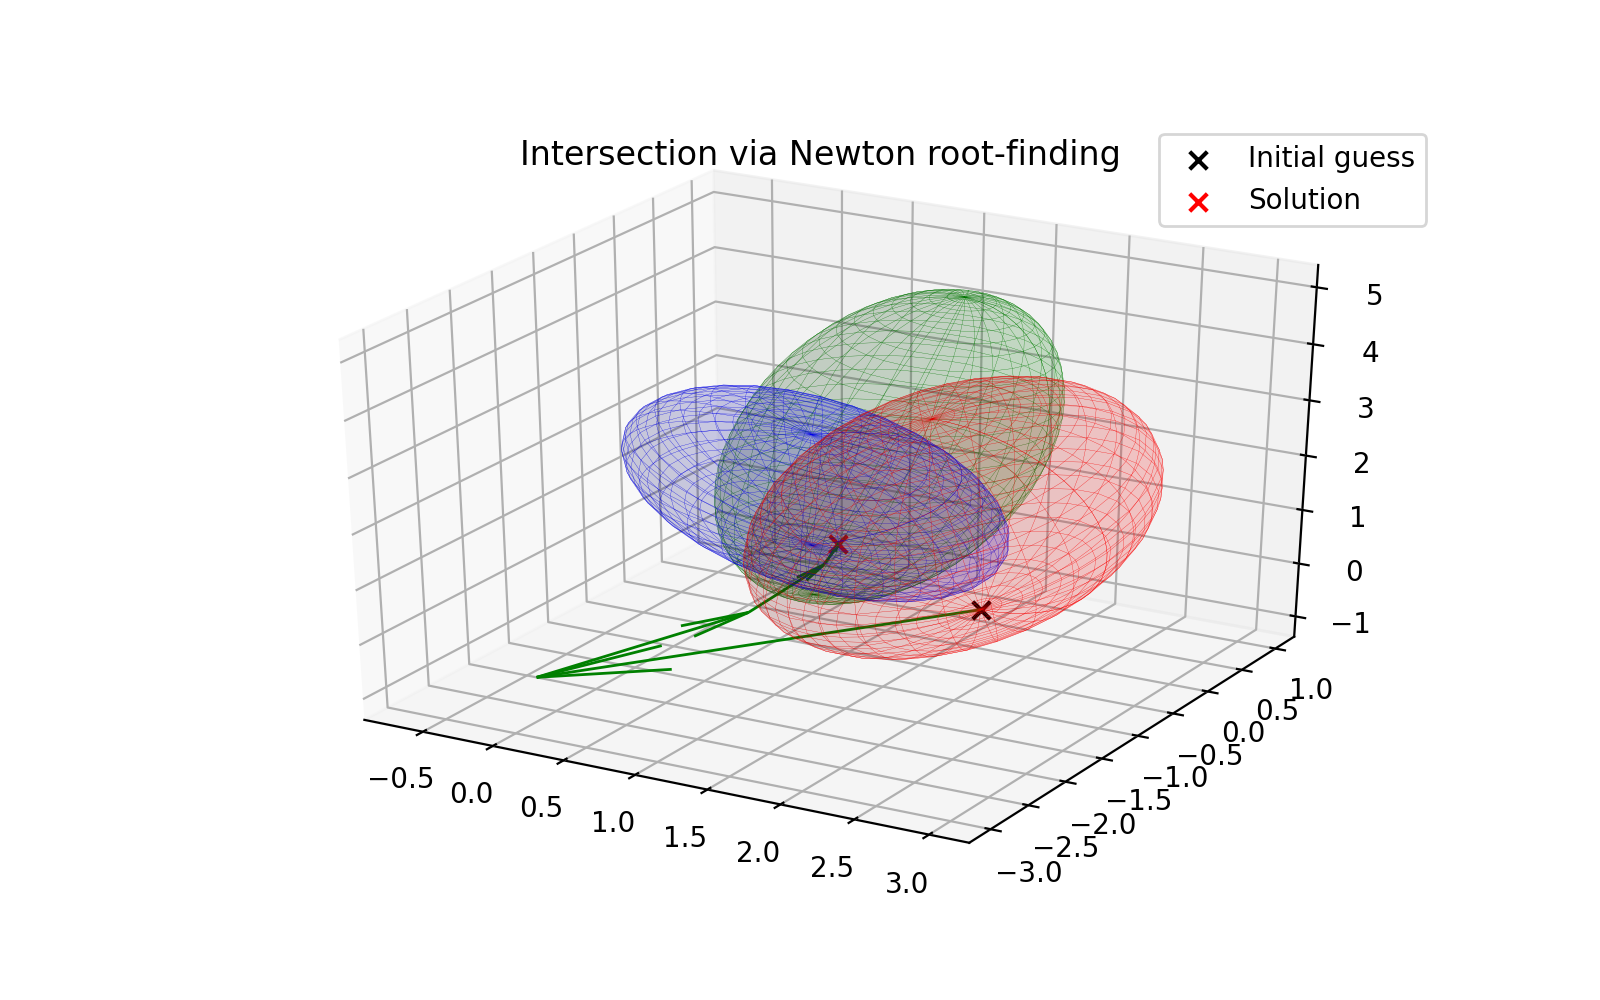

In [8]:
%matplotlib inline
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig, ax = (plt.figure(figsize=(8, 5)), plt.axes(projection='3d'))
ax.set_title('Intersection via Newton root-finding')
for elp, c in zip([elp_a, elp_b, elp_c], ['r', 'g', 'b']):
    xx, yy, zz = elp.coords
    ax.plot_wireframe(xx, yy, zz, color=c, linewidth=.1)
    ax.plot_surface(xx, yy, zz, color=c, alpha=.1)
    
# initial guess and solution
ax.scatter(pts[0][0], pts[0][1], pts[0][2], s=40, marker='x', color='k', label='Initial guess')
ax.scatter(pts[-1][0], pts[-1][1], pts[-1][2], s=40, marker='x', color='red', label='Solution')

# plot gradient steps
x_p = pts[0]
z_p = functional(x_p)[0]
for x_k in pts[1:min(10, len(pts))]:
    ax.quiver(x_p[0], x_p[1], x_p[2], x_k[0]-x_p[0], x_k[1]-x_p[1], x_k[2]-x_p[2], linewidth=1, color='green')
    x_p = x_k

ax.legend()

## Animation Figure

In [9]:
if False:
    from matplotlib import animation
    from IPython.display import HTML

    fig, ax = (plt.figure(figsize=(8, 5)), plt.axes(projection='3d'))
    xx, yy, zz = elp_c.coords
    ax.plot_wireframe(xx, yy, zz, color='purple', linewidth=.25)
    ax.plot_surface(xx, yy, zz, color='purple', alpha=.25)
    ax.set_axis_off()
    ax.view_init(0, 135)
    plt.tight_layout()
    animate = lambda i: ax.view_init(45, 30+i*20)
    anim = animation.FuncAnimation(fig, animate, frames=18, interval=100, repeat=True)
    HTML(anim.to_jshtml())

    anim.save('./data/ellipsoid_anim.gif', writer='imagemagick', fps=10)